# TASK 1: Data Claening And Formating 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, zscore
from datetime import datetime

#### In this step imported required libraries 

In [4]:
df = pd.read_csv("goldman_sachs.csv")
df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,33,CUST6549,ACC12334,Credit,Withdrawal,Savings Account,Firm C,Central,Manager 1,21-10-2023,87480.05448,74008.43310,0.729101,319,200
1,177,CUST2942,ACC52650,Credit,Withdrawal,Home Loan,Firm A,East,Manager 3,20-06-2023,20315.74505,22715.83590,0.472424,692,47
2,178,CUST6776,ACC45101,Current,Deposit,Personal Loan,Firm C,South,Manager 3,02-01-2023,10484.57165,42706.09210,0.648784,543,109
3,173,CUST2539,ACC88252,Current,Withdrawal,Mutual Fund,Firm A,Central,Manager 2,25-07-2023,45122.27373,114176.56870,0.734832,430,103
4,67,CUST2626,ACC21878,Savings,Withdrawal,Home Loan,Firm C,Central,Manager 4,25-07-2023,42360.79878,17863.02644,0.289304,468,234


#### Here data is imported

### 1.1 and 1.2 Remove/treat any special characters or non-numeric entries from financial fields

In [5]:
cols = ['TransactionAmount', 'AccountBalance', 'RiskScore']

for col in cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(r'[^0-9.-]', '', regex=True)
        .astype(float)
    )

In [6]:
df.to_csv("Cleaned_Data.csv", index=False)


In [ ]:
cleaned_df =pd.read_csv("Cleaned_Data.csv")

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,33,CUST6549,ACC12334,Credit,Withdrawal,Savings Account,Firm C,Central,Manager 1,21-10-2023,87480.05448,74008.43310,0.729101,319,200
1,177,CUST2942,ACC52650,Credit,Withdrawal,Home Loan,Firm A,East,Manager 3,20-06-2023,20315.74505,22715.83590,0.472424,692,47
2,178,CUST6776,ACC45101,Current,Deposit,Personal Loan,Firm C,South,Manager 3,02-01-2023,10484.57165,42706.09210,0.648784,543,109
3,173,CUST2539,ACC88252,Current,Withdrawal,Mutual Fund,Firm A,Central,Manager 2,25-07-2023,45122.27373,114176.56870,0.734832,430,103
4,67,CUST2626,ACC21878,Savings,Withdrawal,Home Loan,Firm C,Central,Manager 4,25-07-2023,42360.79878,17863.02644,0.289304,468,234


### 1.3 Validate and format date columns.

In [8]:
changed_date = cleaned_df['TransactionDate'] = pd.to_datetime(cleaned_df['TransactionDate'], dayfirst = True, errors='coerce')


In [9]:
changed_date.to_csv("Task 1_3.csv", index = False)

### 1.4 Ensure account types and transaction categories are standardized.

In [10]:
cleaned_df['AccountType'] = cleaned_df['AccountType'].str.lower().str.strip()
cleaned_df['TransactionType'] = cleaned_df['TransactionType'].str.lower().str.strip()
categories_standardized = cleaned_df.to_csv("Task 1.4.csv")

In [88]:
cleaned_df.head(10)

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,TenureMonths,Month,Year,Txn_Category,Gap,Inactive_Flag,CreditAmount,DebitAmount,TxnNature,Z_Score
468,73,CUST9209,ACC10117,savings,transfer,Credit Card,Firm E,West,Manager 1,2023-01-30,...,60,2023-01,2023,debit,NaN,Active acc,0.00000,57310.76365,Debit,0.197382
25,34,CUST3109,ACC10117,savings,deposit,Home Loan,Firm E,West,Manager 3,2023-02-21,...,85,2023-02,2023,credit,22.0,Active acc,67555.28072,0.00000,Credit,0.549962
87,106,CUST8155,ACC10117,credit,deposit,Mutual Fund,Firm C,East,Manager 3,2023-06-18,...,109,2023-06,2023,credit,117.0,Inactive acc,63248.56067,0.00000,Credit,0.401740
742,169,CUST3810,ACC10117,loan,deposit,Home Loan,Firm B,East,Manager 4,2024-03-14,...,218,2024-03,2024,credit,270.0,Inactive acc,11366.36239,0.00000,Credit,-1.383863
384,158,CUST3041,ACC10996,savings,withdrawal,Credit Card,Firm B,South,Manager 3,2023-05-08,...,233,2023-05,2023,debit,NaN,Active acc,0.00000,11989.50230,Debit,-1.362417
294,93,CUST6776,ACC10996,savings,payment,Savings Account,Firm C,North,Manager 4,2023-10-19,...,103,2023-10,2023,debit,164.0,Inactive acc,0.00000,61653.06253,Debit,0.346828
396,88,CUST6776,ACC10996,credit,transfer,Home Loan,Firm C,North,Manager 2,2023-10-21,...,207,2023-10,2023,debit,2.0,Active acc,0.00000,61545.77749,Debit,0.343136
574,22,CUST6565,ACC10996,current,withdrawal,Mutual Fund,Firm A,Central,Manager 2,2024-01-29,...,201,2024-01,2024,debit,100.0,Inactive acc,0.00000,52970.34507,Debit,0.048000
59,26,CUST9843,ACC10996,credit,deposit,Credit Card,Firm E,North,Manager 4,2024-02-09,...,112,2024-02,2024,credit,11.0,Active acc,62580.86356,0.00000,Credit,0.378760
557,115,CUST8091,ACC11062,credit,payment,Mutual Fund,Firm B,Central,Manager 1,2023-11-08,...,71,2023-11,2023,debit,NaN,Active acc,0.00000,15601.70053,Debit,-1.238098


#### we clean the data by fixing numbers, dates, and categories so the dataset is accurate and ready to use for analysis.

# Task 2: Descriptive Transactional Analysis

### 2.1 Calculate monthly and yearly summaries of total credits, debits, and net transaction

In [11]:
cleaned_df['Month'] = cleaned_df['TransactionDate'].dt.to_period('M')
cleaned_df['Year'] = cleaned_df['TransactionDate'].dt.year

In [12]:
summary = cleaned_df.pivot_table(
    values='TransactionAmount',
    index='Month',
    columns='TransactionType',
    aggfunc='sum'
)
summary['Net'] = summary.get('credit',0) - summary.get('debit',0)

In [91]:
summary.round(2)

TransactionType,deposit,payment,transfer,withdrawal,Net
Month,,,,,
2023-01,738270.10,767715.19,503614.96,1047046.34,0
2023-02,648261.00,354836.66,286550.14,792466.61,0
2023-03,604002.42,865951.65,545314.71,616527.07,0
2023-04,439321.69,590121.52,301770.39,446402.37,0
2023-05,425589.87,906411.88,731136.02,566167.37,0
2023-06,469388.81,214746.05,175645.94,485198.42,0
2023-07,648027.88,175522.17,416423.61,315287.01,0
2023-08,544970.36,607459.32,719074.09,684698.13,0
2023-09,712838.80,411925.53,281986.25,918769.32,0


#### This analysis helps identify transaction trends, high‑value customers, and risky accounts to support better financial monitoring and decision‑making.

In [13]:
summary.to_csv("Task 2_1.csv")

### 2.2 Plot trends in total credits vs. debits over time

In [14]:
cleaned_df['Txn_Category'] =cleaned_df['TransactionType'].map({
    'deposit': 'credit',
    'transfer': 'debit',
    'payment': 'debit',
    'withdrawal': 'debit'
})

In [15]:
monthly_summary = cleaned_df.pivot_table(
    values='TransactionAmount',
    index='Month',
    columns='Txn_Category',
    aggfunc='sum'
)

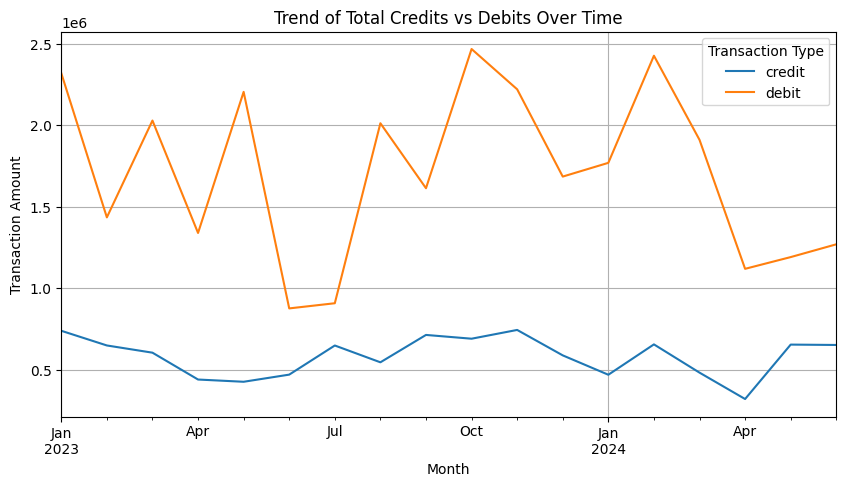

In [16]:
monthly_summary[['credit', 'debit']].plot(figsize=(10,5))

plt.title("Trend of Total Credits vs Debits Over Time")
plt.xlabel("Month")
plt.ylabel("Transaction Amount")
plt.legend(title="Transaction Type")
plt.grid(True)
plt.show()

#### This code classifies transactions into credits and debits, calculates monthly totals for each, and plots their trends over time to compare money inflows and outflows.

### 2.3 dentify top and bottom performing accounts based on net inflow.

In [17]:
account_flow = cleaned_df.groupby('AccountID')['TransactionAmount'].sum()

top_accounts = account_flow.sort_values(ascending=False).head(10)
bottom_accounts = account_flow.sort_values().head(10)

In [92]:
print(top_accounts)

AccountID
ACC46655    728037.402705
ACC33287    591591.095890
ACC16241    539612.142850
ACC53466    494957.158800
ACC29396    482720.015550
ACC83269    468734.595390
ACC57700    465047.926414
ACC60432    462957.849880
ACC29356    435573.496188
ACC13357    432527.808260
Name: TransactionAmount, dtype: float64


In [93]:
print(bottom_accounts)

AccountID
ACC46953   -24811.428950
ACC11062     4014.264900
ACC43771    14033.502560
ACC87602    14944.062400
ACC26956    15603.452120
ACC21429    20442.761880
ACC78089    26828.979199
ACC62809    34979.062450
ACC29007    35207.179489
ACC29646    36055.574280
Name: TransactionAmount, dtype: float64


#### this show the best and worst performing accounts based on net inflow, helping the bank recognize high‑value customers and flag accounts with consistently negative cash flow for closer monitoring.

### 2.4 Identify and flag accounts as dormant or inactive if there is a gap of two months or more
### between consecutive transactions.

In [18]:
cleaned_df = cleaned_df.sort_values(['AccountID','TransactionDate'])

cleaned_df['Gap'] = cleaned_df.groupby('AccountID')['TransactionDate'].diff().dt.days

cleaned_df['Inactive_Flag'] = cleaned_df['Gap'].apply(lambda x: "Inactive acc" if x >= 60 else "Active acc")

In [98]:
cleaned_df[["Inactive_Flag","AccountID"]]

,Inactive_Flag,AccountID
468,Active acc,ACC10117
25,Active acc,ACC10117
87,Inactive acc,ACC10117
742,Inactive acc,ACC10117
384,Active acc,ACC10996
...,...,...
542,Inactive acc,ACC99409
223,Active acc,ACC99549
504,Inactive acc,ACC99549
706,Inactive acc,ACC99549


#### This analysis identifies dormant or inactive accounts based on long gaps between transactions, helping the bank flag inactive customers for re‑engagement or risk monitoring.

In [19]:
cleaned_df.to_csv("Task 2.4.csv")

# 3 Customer Profile Building 

### 3.1 Group accounts by activity levels: High, Medium, Low based on transaction frequency on
### your analysis and rubrics. Do not forget to mention the rubric in the headings.

In [20]:
transction_frequency = (
    cleaned_df
    .groupby('AccountID')
    .size()
    .reset_index(name='TxnCount')   
)
def activity_level(count):
    if count > 20:
        return 'High'
    elif count >= 10:
        return 'Medium'
    else:
        return 'Low'

transction_frequency['ActivityLevel'] = (
    transction_frequency['TxnCount'].apply(activity_level)
)
activity_balance = transction_frequency.merge(
    cleaned_df.groupby('AccountID')['AccountBalance']
        .mean()
        .reset_index(),
    on='AccountID'
)

transction_frequency['ActivityLevel'] = transction_frequency['TxnCount'].apply(activity_level)

In [99]:
transction_frequency[["ActivityLevel","AccountID"]]

,ActivityLevel,AccountID
0,Low,ACC10117
1,Low,ACC10996
2,Low,ACC11062
3,Low,ACC11188
4,Low,ACC11285
...,...,...
189,Low,ACC97225
190,Low,ACC97411
191,Low,ACC99117
192,Low,ACC99409


#### This analysis groups accounts into high, medium, and low activity levels based on transaction frequency, helping identify highly engaged customers and low‑activity accounts that may need re‑engagement or closer monitoring.


In [23]:
transction_frequency.to_csv("Task 3_1.csv")

### 3.2 Segment customers by average balance and transaction volume

In [24]:
customer_profile = cleaned_df.groupby('AccountID').agg(
    AvgBalance=('AccountBalance', 'mean'),
    TotalTxnVolume=('TransactionAmount', 'sum')
).reset_index()


In [25]:
balance_median = customer_profile['AvgBalance'].median()
volume_median = customer_profile['TotalTxnVolume'].median()


In [26]:
def segment_customer(row):
    if row['AvgBalance'] > balance_median and row['TotalTxnVolume'] > volume_median:
        return 'High Balance – High Volume'
    elif row['AvgBalance'] > balance_median and row['TotalTxnVolume'] <= volume_median:
        return 'High Balance – Low Volume'
    elif row['AvgBalance'] <= balance_median and row['TotalTxnVolume'] > volume_median:
        return 'Low Balance – High Volume'
    else:
        return 'Low Balance – Low Volume'

customer_profile['CustomerSegment'] = customer_profile.apply(segment_customer, axis=1)


In [27]:
segment_summary = customer_profile['CustomerSegment'].value_counts()
segment_summary


CustomerSegment
Low Balance – Low Volume      49
High Balance – High Volume    49
Low Balance – High Volume     48
High Balance – Low Volume     48
Name: count, dtype: int64

In [100]:
customer_profile

,AccountID,AvgBalance,TotalTxnVolume,CustomerSegment
0,ACC10117,70107.007957,199480.967430,Low Balance – Low Volume
1,ACC10996,43568.008084,250739.550950,Low Balance – High Volume
2,ACC11062,38137.132610,4014.264900,Low Balance – Low Volume
3,ACC11188,69652.151044,257576.603590,Low Balance – High Volume
4,ACC11285,97401.348560,96729.609841,High Balance – Low Volume
...,...,...,...,...
189,ACC97225,38652.306677,160282.714280,Low Balance – Low Volume
190,ACC97411,55978.315635,174551.560470,Low Balance – Low Volume
191,ACC99117,47228.185087,212848.743280,Low Balance – High Volume
192,ACC99409,83743.915565,113191.225750,High Balance – Low Volume


#### This segmentation divides customers into four groups based on average balance and transaction volume, helping the bank identify high‑value customers, frequent low‑balance users, and low‑engagement accounts for targeted strategies.

In [29]:
customer_profile.to_csv("Task 3_2.csv")

### 3.3.1 High-net inflow accounts

In [30]:
# Separate credit and debit amounts
cleaned_df['CreditAmount'] = cleaned_df.apply(
    lambda x: x['TransactionAmount'] if x['Txn_Category'] == 'credit' else 0,
    axis=1
)

cleaned_df['DebitAmount'] = cleaned_df.apply(
    lambda x: x['TransactionAmount'] if x['Txn_Category'] == 'debit' else 0,
    axis=1
)

# Net inflow per account
net_inflow = cleaned_df.groupby('AccountID').agg(
    TotalCredit=('CreditAmount', 'sum'),
    TotalDebit=('DebitAmount', 'sum')
)

net_inflow['NetInflow'] = net_inflow['TotalCredit'] - net_inflow['TotalDebit']

# High‑net inflow accounts
high_net_inflow_accounts = net_inflow[net_inflow['NetInflow'] > 0]


In [101]:
high_net_inflow_accounts 


,TotalCredit,TotalDebit,NetInflow
AccountID,,,
ACC10117,142170.20378,57310.763650,84859.440130
ACC15359,122856.48300,120413.197880,2443.285120
ACC18140,45680.91092,38542.747670,7138.163250
ACC19178,64100.78213,0.000000,64100.782130
ACC21264,79561.48165,58077.649160,21483.832490
ACC21878,112600.88690,42360.798780,70240.088120
ACC24508,36340.30994,0.000000,36340.309940
ACC29477,108199.42190,49541.181310,58658.240590
ACC29646,36055.57428,0.000000,36055.574280


#### This analysis identifies high net inflow accounts by comparing total credits and debits, helping the bank recognize financially strong customers with consistent positive cash flow for retention and premium services.

In [31]:
high_net_inflow_accounts.to_csv("Task 3_3_1.csv")

### 3.3.2 High-frequency low-balance accounts

In [32]:
# Transaction frequency per account
transction_frequency = cleaned_df.groupby('AccountID').size()

# Average balance per account
avg_balance = cleaned_df.groupby('AccountID')['AccountBalance'].mean()

# Combine
hf_lb = pd.concat([transction_frequency, avg_balance], axis=1)
hf_lb.columns = ['TxnCount', 'AvgBalance']

# Thresholds
freq_median = hf_lb['TxnCount'].median()
balance_median = hf_lb['AvgBalance'].median()

# High‑frequency, low‑balance accounts
high_freq_low_balance_accounts = hf_lb[
    (hf_lb['TxnCount'] > freq_median) &
    (hf_lb['AvgBalance'] < balance_median)
]


In [102]:
high_freq_low_balance_accounts

,TxnCount,AvgBalance
AccountID,,
ACC10996,5,43568.008084
ACC11188,5,69652.151044
ACC13357,6,69179.806513
ACC18177,5,63505.219474
ACC23736,7,60801.533102
ACC24070,5,55694.967801
ACC26973,5,58738.210687
ACC28292,10,51228.003570
ACC30787,5,60525.872356


#### This analysis identifies accounts with frequent transactions but low average balances, highlighting customers who are highly active yet financially constrained and may need balance management support or closer monitoring.

In [33]:
high_freq_low_balance_accounts.to_csv("Task 3_3_2.csv")

### 3.3.3. Accounts with negative or near-zero balances

In [105]:
zerobalace_account_or_negative_account = avg_balance[
    avg_balance <= 1000
]


In [106]:
zerobalace_account_or_negative_account

AccountID
ACC19178   -1541.176812
Name: AccountBalance, dtype: float64

#### This analysis identifies accounts with negative or near‑zero balances, helping flag financially stressed customers who may require overdraft monitoring, alerts, or corrective action.

In [35]:
zerobalace_account_or_negative_account.to_csv("Task 3_3_3.csv")


# Task 4: Financial Risk Identification

### 4.1 Track accounts with frequent large withdrawals or overdrafts.

In [36]:
cleaned_df['TxnNature'] = cleaned_df['TransactionType'].map({
    'deposit': 'Credit',
    'withdrawal': 'Debit',
    'payment': 'Debit',
    'transfer': 'Debit'
})

In [108]:
# Filter large withdrawals
large_withdrawals = cleaned_df[
    (cleaned_df['TransactionType'] == 'withdrawal') &
    (cleaned_df['TransactionAmount'] > 50000)
]

# Count per account
large_withdrawal_count = large_withdrawals.groupby('AccountID').size().reset_index(
    name='LargeWithdrawalCount'
)



In [107]:
# View result
large_withdrawal_count.head()

,AccountID,LargeWithdrawalCount
0,ACC10996,1
1,ACC11188,1
2,ACC12334,1
3,ACC15228,2
4,ACC15359,1


In [110]:
# Filter overdraft transactions
overdrafts = cleaned_df[cleaned_df['AccountBalance'] < 0]

# Count per account
overdraft_count = overdrafts.groupby('AccountID').size().reset_index(
    name='OverdraftCount'
)

# View result
overdraft_count

,AccountID,OverdraftCount
0,ACC16241,1
1,ACC19178,1
2,ACC23736,1
3,ACC26973,1
4,ACC28154,1
5,ACC28292,2
6,ACC29477,1
7,ACC33287,1
8,ACC49774,1
9,ACC58667,1


#### This analysis identifies accounts with frequent large withdrawals, helping flag potentially risky or stressed accounts that require closer monitoring for overdrafts or unusual cash outflows.

In [39]:
large_withdrawals.to_csv("Task 4_1.csv")

### 4.2 Calculate balance volatility using standard deviation or coefficient of variation.

In [40]:
# standard deviation
balance_stats = cleaned_df.groupby('AccountID')['AccountBalance'].agg(
    MeanBalance='mean',
    StdBalance='std'
).reset_index()

In [41]:
balance_stats['CV'] = (
    balance_stats['StdBalance'] / balance_stats['MeanBalance']
)

In [109]:
balance_stats

,AccountID,MeanBalance,StdBalance,CV
0,ACC10117,70107.007957,25886.972758,0.369249
1,ACC10996,43568.008084,9434.002316,0.216535
2,ACC11062,38137.132610,3208.737888,0.084137
3,ACC11188,69652.151044,35494.660810,0.509599
4,ACC11285,97401.348560,55922.732441,0.574147
...,...,...,...,...
189,ACC97225,38652.306677,28069.592780,0.726207
190,ACC97411,55978.315635,7871.678922,0.140620
191,ACC99117,47228.185087,20780.582578,0.440004
192,ACC99409,83743.915565,21429.756821,0.255896


#### This analysis measures balance volatility using standard deviation and coefficient of variation to identify accounts with unstable balances that may indicate higher financial risk or irregular behavior.

In [42]:
balance_stats.to_csv("Task 4_2.csv")

### 4.3 Use IQR or z-score methods to detect anomalies

In [43]:
cleaned_df['Z_Score'] = (
    (cleaned_df['TransactionAmount'] - cleaned_df['TransactionAmount'].mean()) /
    cleaned_df['TransactionAmount'].std()
)

In [44]:
anomalies = cleaned_df[abs(cleaned_df['Z_Score']) > 3]

In [45]:
anomaly_count = anomalies.groupby('AccountID').size().reset_index(
    name='AnomalyCount'
)

In [46]:
anomalies 
#no anomalies found

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,TenureMonths,Month,Year,Txn_Category,Gap,Inactive_Flag,CreditAmount,DebitAmount,TxnNature,Z_Score


#### This analysis uses the Z‑score method to detect unusually large or abnormal transactions, helping identify potential anomalies or suspicious activities that may require further investigation.

### 4.4 Highlight customers with irregular or suspicious transaction behavior.

In [47]:
suspicious_df = large_withdrawal_count.merge(
    overdraft_count, on='AccountID', how='outer'
).merge(
    anomaly_count, on='AccountID', how='outer'
)

suspicious_df.fillna(0, inplace=True)

In [48]:
suspicious_df['SuspiciousFlag'] = suspicious_df.apply(
    lambda x: 'Suspicious' if (
        x['LargeWithdrawalCount'] > 0 or
        x['OverdraftCount'] > 0 or
        x['AnomalyCount'] > 0
    ) else 'Normal',
    axis=1
)

In [111]:
suspicious_customers = suspicious_df[
    suspicious_df['SuspiciousFlag'] == 'Suspicious'
]

suspicious_customers

,AccountID,LargeWithdrawalCount,OverdraftCount,AnomalyCount,SuspiciousFlag
0,ACC10996,1.0,0.0,0.0,Suspicious
1,ACC11188,1.0,0.0,0.0,Suspicious
2,ACC12334,1.0,0.0,0.0,Suspicious
3,ACC15228,2.0,0.0,0.0,Suspicious
4,ACC15359,1.0,0.0,0.0,Suspicious
...,...,...,...,...,...
90,ACC91723,1.0,0.0,0.0,Suspicious
91,ACC92558,1.0,0.0,0.0,Suspicious
92,ACC94242,2.0,1.0,0.0,Suspicious
93,ACC94907,1.0,0.0,0.0,Suspicious


#### This step combines multiple risk indicators—large withdrawals, overdrafts, and anomalies—to flag customers with suspicious transaction behavior for focused monitoring and further investigation.

In [50]:
suspicious_customers.to_csv("Task 4_3.csv")

# Task 5: Visualisation

### Conduct extensive exploratory data analysis with attractive visualizations for your
### findings

## Distribution of Transaction Amounts

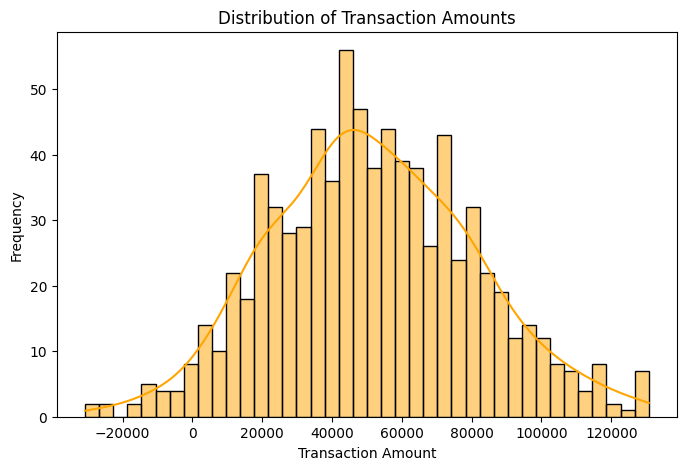

In [51]:
plt.figure(figsize=(8,5))
sns.histplot(cleaned_df['TransactionAmount'], bins=40, kde=True, color="orange")
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

#### This graph shows that most transactions are of medium value, while very small and very large transactions are less frequent, indicating a normal spending pattern with few extremes.

## Transaction Type Distribution

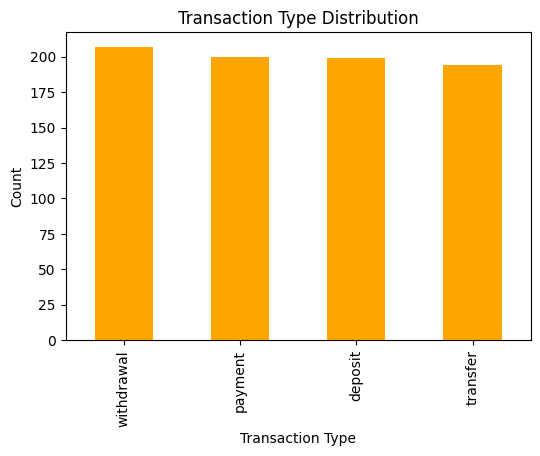

In [52]:
txn_type_counts = cleaned_df['TransactionType'].value_counts()

plt.figure(figsize=(6,4))
txn_type_counts.plot(kind='bar', color="orange" )
plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

#### This graph shows that all transaction types occur in similar numbers, indicating a balanced mix of withdrawals, payments, deposits, and transfers.

## Monthly Transaction Count Trend

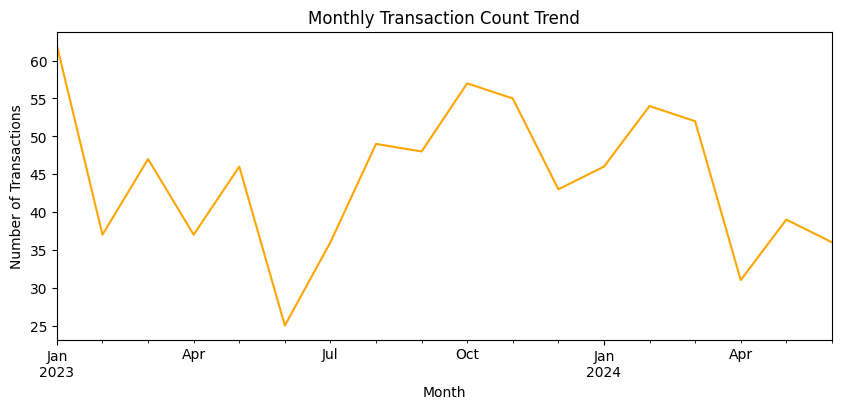

In [53]:
monthly_txn_count = cleaned_df.groupby('Month').size()

plt.figure(figsize=(10,4))
monthly_txn_count.plot(color = "orange")
plt.title("Monthly Transaction Count Trend")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.show()

#### This graph shows that the number of transactions changes from month to month, indicating seasonal or periodic variations in customer activity.

## Transaction Amount vs Account Balance

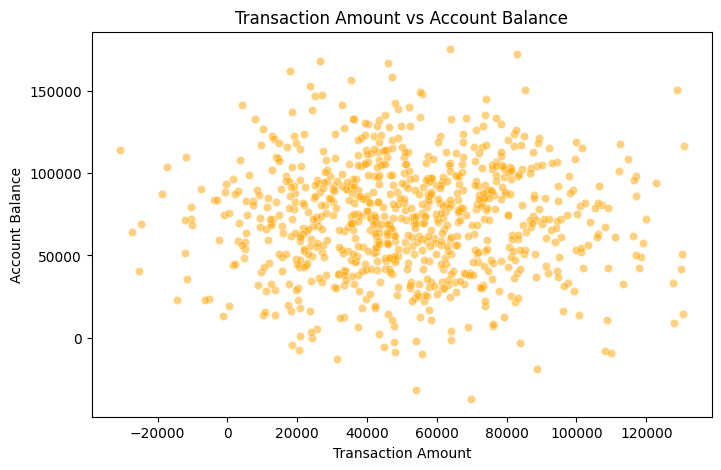

In [54]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=cleaned_df['TransactionAmount'],
    y=cleaned_df['AccountBalance'],
    alpha=0.5, color = "orange"
)
plt.title("Transaction Amount vs Account Balance")
plt.xlabel("Transaction Amount")
plt.ylabel("Account Balance")
plt.show()

#### This graph shows no strong direct relationship between transaction amount and account balance, meaning high transactions do not always result in high balances.

## Distribution of Balance Volatility (CV)

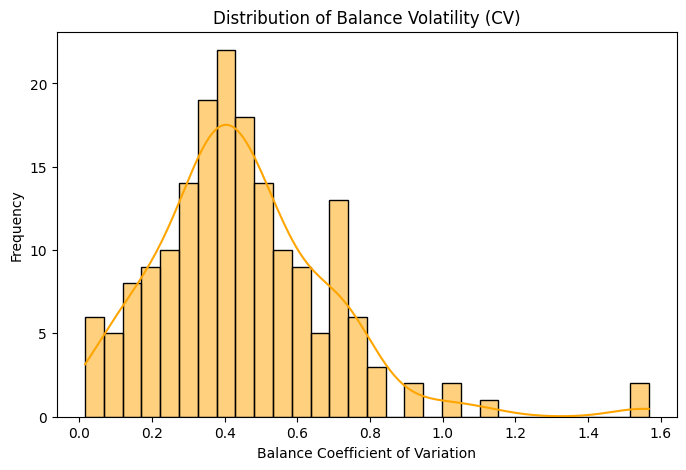

In [55]:
plt.figure(figsize=(8,5))
sns.histplot(balance_stats['CV'], bins=30, kde=True, color= "orange")
plt.title("Distribution of Balance Volatility (CV)")
plt.xlabel("Balance Coefficient of Variation")
plt.ylabel("Frequency")
plt.show()

#### This graph shows that most accounts have moderate balance changes, while a few accounts have very high volatility, indicating unstable or risky balance behavior.

## Activity Level vs Average Balance

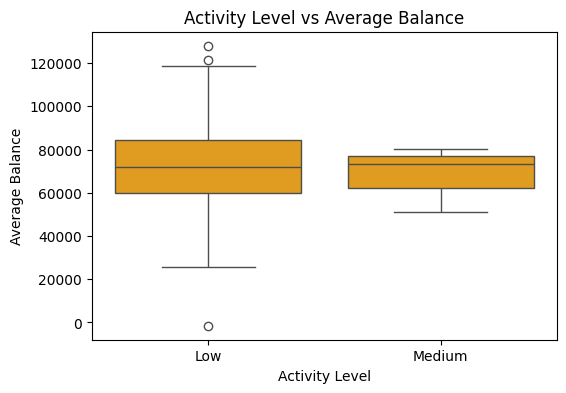

In [ ]:
transction_frequency = (
    cleaned_df
    .groupby('AccountID')
    .size()
    .reset_index(name='TxnCount')   
)
def activity_level(count):
    if count > 20:
        return 'High'
    elif count >= 10:
        return 'Medium'
    else:
        return 'Low'

transction_frequency['ActivityLevel'] = (
    transction_frequency['TxnCount'].apply(activity_level)
)
activity_balance = transction_frequency.merge(
    cleaned_df.groupby('AccountID')['AccountBalance']
        .mean()
        .reset_index(),
    on='AccountID'
)
plt.figure(figsize=(6,4))
sns.boxplot(
    x=activity_balance['ActivityLevel'],
    y=activity_balance['AccountBalance'],
    color= "orange"
)
plt.title("Activity Level vs Average Balance")
plt.xlabel("Activity Level")
plt.ylabel("Average Balance")
plt.show()


#### This graph shows that medium‑activity accounts generally maintain more stable and higher average balances, while low‑activity accounts have wider balance variation and more extreme values.

## Risk Score Distribution

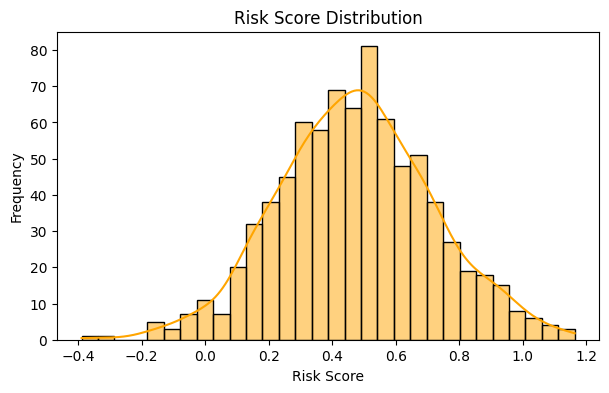

In [57]:
plt.figure(figsize=(7,4))
sns.histplot(df['RiskScore'], bins=30, kde=True, color="orange" )
plt.title("Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")
plt.show()

#### This graph shows that most customers have a medium risk score, while only a small number fall into very low or very high risk categories.






# task 6 Hypothesis Testing 

### 6.1 and 6.2
### Test whether high-volume transaction accounts have statistically higher average
### balances than low-volume accounts.
### Conduct hypothesis testing based on segmentation.

In [ ]:
# account-level summary

account_summary = cleaned_df.groupby('AccountID').agg(
    Transaction_Count=('TransactionAmount', 'count'),
    Avg_Balance=('AccountBalance', 'mean')
).reset_index()

print("\nAccount-level summary")
print(account_summary.head())




Account-level summary
  AccountID  Transaction_Count   Avg_Balance
0  ACC10117                  4  70107.007957
1  ACC10996                  5  43568.008084
2  ACC11062                  2  38137.132610
3  ACC11188                  5  69652.151044
4  ACC11285                  3  97401.348560


In [ ]:
# Segment accounts by transaction volume



avg_txn_count = account_summary['Transaction_Count'].mean()

high_volume_accounts = account_summary[
    account_summary['Transaction_Count'] > avg_txn_count
]

low_volume_accounts = account_summary[
    account_summary['Transaction_Count'] <= avg_txn_count
]

print("\nSegmentation results")
print("Average transaction count:", round(avg_txn_count, 2))
print("High-volume accounts:", high_volume_accounts.shape[0])
print("Low-volume accounts:", low_volume_accounts.shape[0])



Segmentation results
Average transaction count: 4.12
High-volume accounts: 73
Low-volume accounts: 121


In [ ]:

# Compare average balances

high_avg_balance = high_volume_accounts['Avg_Balance']
low_avg_balance = low_volume_accounts['Avg_Balance']

print("\nAverage balances")
print("High-volume avg balance:", round(high_avg_balance.mean(), 2))
print("Low-volume avg balance:", round(low_avg_balance.mean(), 2))


Average balances
High-volume avg balance: 72512.19
Low-volume avg balance: 71683.28


In [ ]:

# Perform TWO-SAMPLE T-TEST

t_stat, p_value = ttest_ind(
    high_avg_balance,
    low_avg_balance,
    equal_var=False
)

print("\nHypothesis test results")
print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 4))



Hypothesis test results
T-statistic: 0.3151
P-value: 0.7531


In [ ]:

# Hypothesis decision 

alpha = 0.05

print("\nDecision")
if p_value < alpha:
    print("Reject H0: High-volume accounts have significantly higher average balances.")
else:
    print("Fail to reject H0: No significant difference in average balances.")



# DISPLAY TABLES
print("\nHigh-volume accounts sample")
display(high_volume_accounts.head())
print("\nLow-volume accounts sample")
display(low_volume_accounts.head())



Decision
Fail to reject H0: No significant difference in average balances.

High-volume accounts sample


,AccountID,Transaction_Count,Avg_Balance
1,ACC10996,5,43568.008084
3,ACC11188,5,69652.151044
7,ACC12334,6,78082.517883
8,ACC13357,6,69179.806513
9,ACC15228,5,95389.614144



Low-volume accounts sample


,AccountID,Transaction_Count,Avg_Balance
0,ACC10117,4,70107.007957
2,ACC11062,2,38137.132610
4,ACC11285,3,97401.348560
5,ACC11837,4,84852.733695
6,ACC12182,4,83837.145895


#### This hypothesis test compares high‑volume and low‑volume transaction accounts and finds no statistically significant difference in their average balances, as the p‑value is greater than 0.05.
#### based on hypothesis testing, there is no statistically significant difference in average balances between high‑volume and low‑volume transaction accounts, indicating that transaction frequency alone does not strongly influence account balance levels.

## Recommendations
#### The bank should closely monitor accounts with irregular behavior, such as frequent large withdrawals, overdrafts, high balance volatility, or anomalous transactions, to reduce financial risk.

#### High‑value and high‑activity customers can be targeted with personalized offers, premium services, or retention strategies.

#### Inactive or low‑engagement accounts should be identified for re‑engagement campaigns or operational review.

#### Implementing automated alerts and dashboards based on these risk indicators can improve fraud detection and decision‑making efficiency.